# Up and Out Barrier Option


In [48]:
import numpy as np
import matplotlib.pyplot as plt


seed = 123
rng = np.random.default_rng(seed)

In [49]:
def call_payoff(S_T, K):
    return np.maximum(S_T - K, 0)

def put_payoff(S_T, K):
    return np.maximum(K - S_T, 0)

Simulate price paths with euler:

In [50]:
# The Euler discretization simulates the price path step by step
def euler_discretization(S0, r, sigma, T, dt, rng):
    N = int(T/dt)  # number of time steps
    times = np.linspace(0, T, N+1)
    S = {times[0]: S0}
    
    for t in range(1, N+1):
        error = rng.standard_normal()  # generate standard normal random variables
        S[times[t]] = S[times[t-1]] *(1 + r * dt + sigma * np.sqrt(dt) * error)
    return S

In [51]:
S0 = 100  # initial stock price
K = 100   # strike price for call option
r = 0.05  # risk-free interest rate
T = 1.0   # time to maturity in years
sigma = 0.2  # volatility
n_simulations = 1000 # number of Monte Carlo simulations
dt = 0.01  # time step for Euler discretization
up_out = 130


In [52]:
payoffs = []
S_paths = []
for _ in range(n_simulations):
    S_path = euler_discretization(S0, r, sigma, T, dt, rng)
    S_paths.append(S_path)
    S_T = list(S_path.values())[-1]
    if max(S_path.values()) < up_out:
        payoff = call_payoff(S_T, K) 
        
    else:
        payoffs.append(0)
    payoffs.append(payoff)
option_price = np.exp(-r * T) * np.mean(payoffs)
print(f"Estimated price of the up-and-out barrier call option: {option_price:.2f}")

Estimated price of the up-and-out barrier call option: 3.76


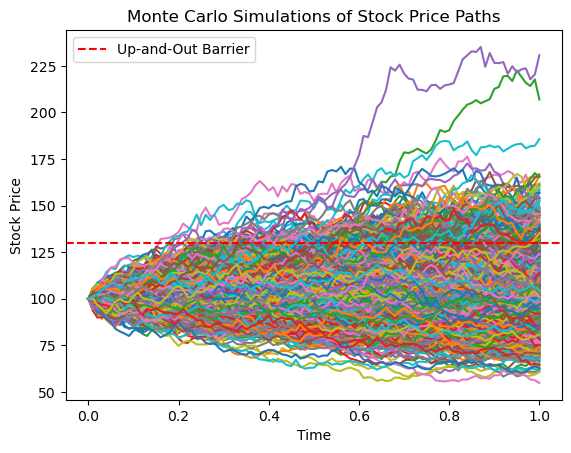

In [53]:
for path in S_paths:
    times = list(path.keys())
    prices = list(path.values())
    plt.plot(times, prices)
plt.axhline(y=up_out, color='r', linestyle='--', label='Up-and-Out Barrier')
plt.legend()
plt.title('Monte Carlo Simulations of Stock Price Paths')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.show()

# Put

In [54]:
payoffs = []
S_paths = []
for _ in range(n_simulations):
    S_path = euler_discretization(S0, r, sigma, T, dt, rng)
    S_paths.append(S_path)
    S_T = list(S_path.values())[-1]
    if max(S_path.values()) < up_out:
        payoff = put_payoff(S_T, K) 
        
    else:
        payoffs.append(0)
    payoffs.append(payoff)
option_price = np.exp(-r * T) * np.mean(payoffs)
print(f"Estimated price of the up-and-out barrier put option: {option_price:.2f}")

Estimated price of the up-and-out barrier put option: 6.28
